# Plotting Ternary Phase Diagrams and Using Triangular Axes

Often in thermodynamics, it is useful to use a two dimensional plot to express equilibria in a three component system with fixed potentials. The `ternplot` API provides a straightforward way to calculate equilibria and generate ternary phase diagrams. Alternatively, if you already have an equilibrium calculation, you can directly import and use `eqplot`.

## ternplot

Here we will use the `ternplot` API to plot an isothermal section of the Cr-Fe-Nb system from the thermodynamic database found at [Liquidus projection and thermodynamic modeling of the Cr-Fe-Nb ternary system by Jacob et al., Calphad 54 (2016) 1-15](https://doi.org/10.1016/j.calphad.2016.04.013)

Wall Time (Total elapsed): 21 s


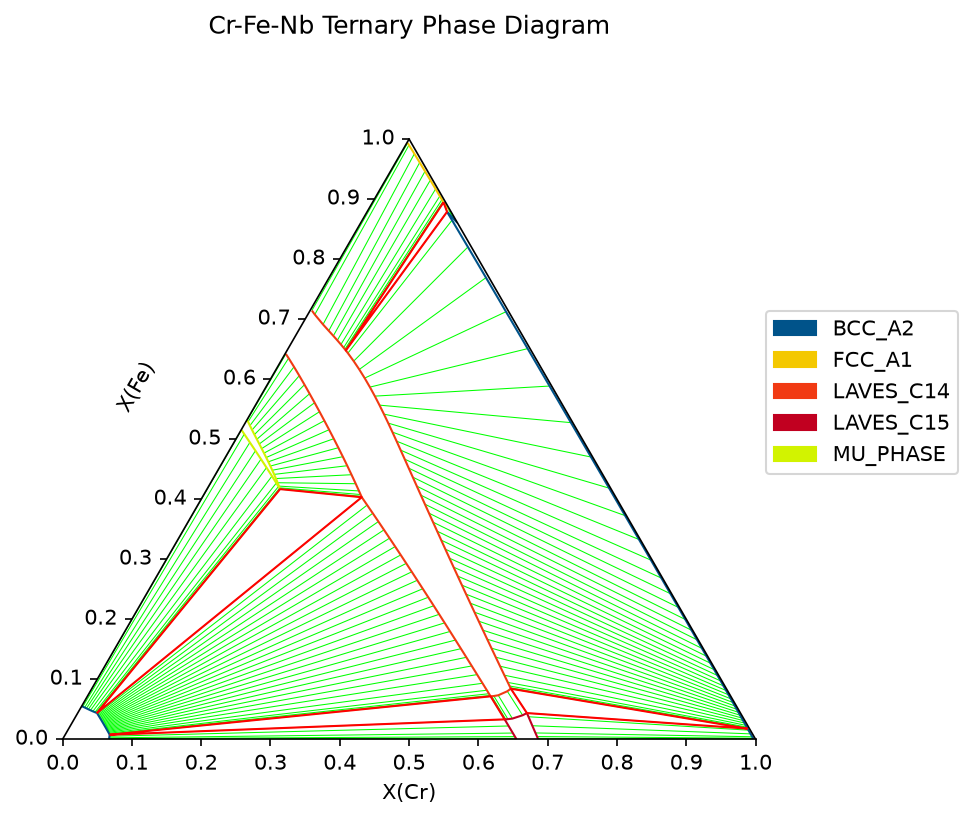

In [1]:
import time
import matplotlib.pyplot as plt
from pycalphad import Database, ternplot
from pycalphad import variables as v

db_cr_fe_nb = Database('../databases/CrFeNb_Jacob2016.tdb')
comps = ['CR', 'FE', 'NB', 'VA']
phases = list(db_cr_fe_nb.phases.keys())
conds = {v.T: 1323, v.P:101325, v.X('CR'): (0,1,0.015), v.X('FE'): (0,1,0.015)}

start_time = time.perf_counter()

ax = ternplot(db_cr_fe_nb, comps, phases, conds, x=v.X('CR'), y=v.X('FE'))
fig = ax.figure
ax.set_title("Cr-Fe-Nb Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

end_time = time.perf_counter()

print(f"Wall Time (Total elapsed): {round(end_time - start_time)} s")

Here is another example for plotting the isothermal section of the Al-Cu-Y system from the thermodynamic database found at the [NIST CALPHAD assessments](http://hdl.handle.net/11115/101) assessed [by Zhang et al. in Thermodynamic description of the Al–Cu–Y ternary system  (Calphad 35 (2011))](https://doi.org/10.1016/j.calphad.2011.09.008). Labels for phases in the three-phase equilibria can be added for clarity.

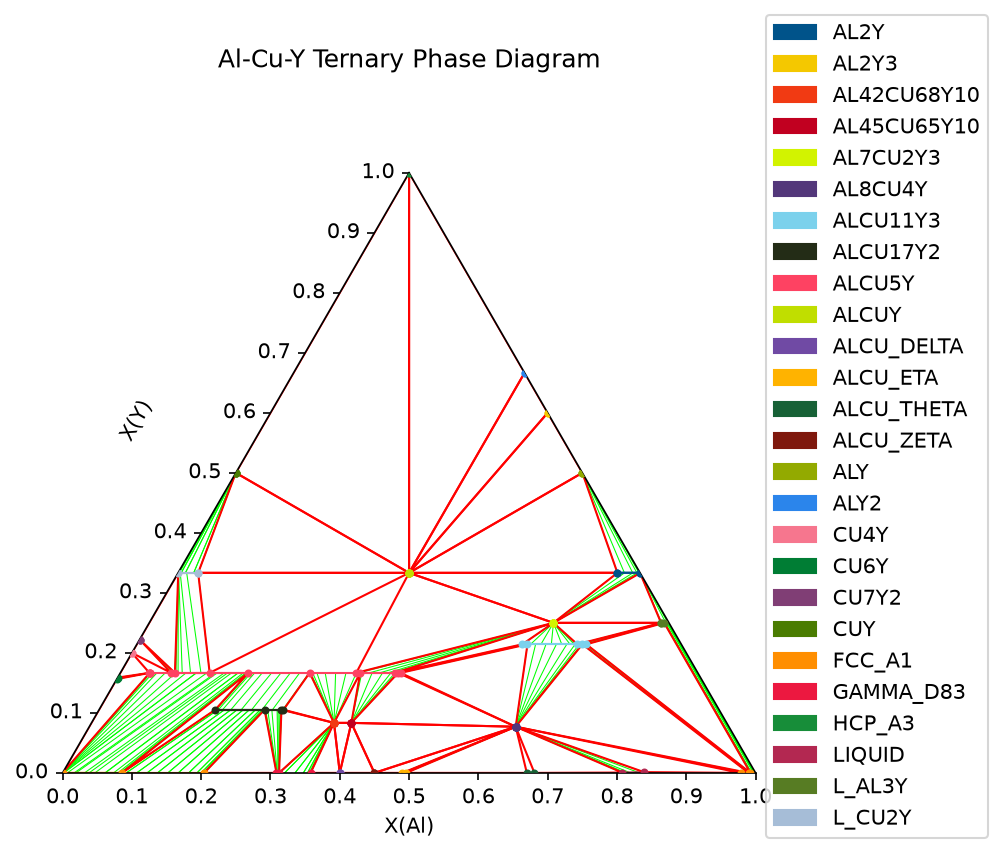

In [2]:
db_al_cu_y = Database('../databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 830, v.P:101325, v.X('AL'): (0,1,0.015), v.X('Y'): (0,1,0.015)}

ax = ternplot(db_al_cu_y, comps, phases, conds, x=v.X('AL'), y=v.X('Y'), label_nodes=True)
fig = ax.figure
ax.set_title("Al-Cu-Y Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

By default, the mapping code will attempt to generate a list of starting points by searching around the axes of the phase diagram. However, in some cases, phase regions in the phase diagram will not connect to the axis. This is the case if we want to plot the Al-Cu-Y ternary at higher temperatures (e.g. >1360 K). The following will show how to use the mapping API to add custom starting points to generate the correct phase diagram.

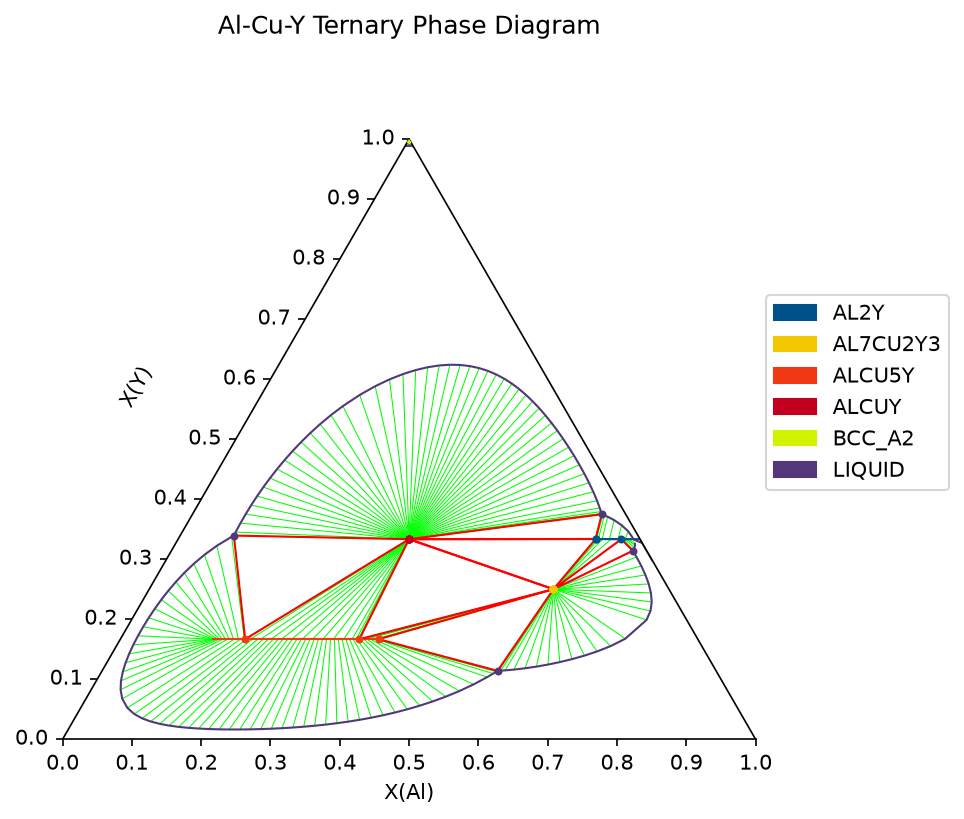

In [3]:
from pycalphad.mapping import TernaryStrategy, plot_ternary

db_al_cu_y = Database('../databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 1770, v.P:101325, v.X('AL'): (0,1,0.015), v.X('Y'): (0,1,0.015)}
strat = TernaryStrategy(db_al_cu_y, comps, phases, conds)

# Add automatic starting points by searching along the axes
strat.generate_automatic_starting_points()

# Add custom starting point near middle of phase diagram
strat.add_nodes_from_conditions({v.T: 1770, v.P: 101325, v.X('AL'): 0.35, v.X('Y'): 0.3})
strat.do_map()

ax = plot_ternary(strat, x=v.X('AL'), y=v.X('Y'), label_nodes=True)
fig = ax.figure
ax.set_title("Al-Cu-Y Ternary Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)

## Molar Ratios and Linear Combination Conditions

In [4]:
from pycalphad import Workspace

db_al_cu_y = Database('../databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
phases = list(db_al_cu_y.phases.keys())
conds = {v.T: 830, v.P:101325,
         v.X('AL')/v.X('CU'): 5, # molar ratio condition
         0.1 * v.X('Y') + v.X('AL'): 0.6} # linear combination of mole fractions condition
wks = Workspace(db_al_cu_y, comps, phases, conds)
x_al, x_cu, x_y = wks.get('X(AL)', 'X(CU)', 'X(Y)')

print(f"X(Al) = {x_al:.2f}\nX(Cu) = {x_cu:.2f}\nX(Y) = {x_y:.2f}")

X(Al) = 0.57
X(Cu) = 0.11
X(Y) = 0.32


## ChemSage `.dat` databases and the modified quasichemical model

All examples above load TDB files, but PyCalphad's `Database` also reads ChemSage `.dat` files. ChemSage `.dat` files can contain phases that use the **modified quasichemical model in the quadruplet approximation (MQMQA)**, which represents short-range ordering in ionic liquids (slags, molten salts) with pairs or quadruplet species.

Below we load the Fe-Sb-O-S slag database ([D. Shishin, T. Hidayat, J. Chen, P. Hayes, E. Jak, CALPHAD 65 (2019) 16-24](https://doi.org/10.1016/j.calphad.2019.01.016)) containing a MQMQA model for slag. All other PyCalphad code works identically.



In [5]:
from importlib.resources import files
import pycalphad.tests.databases
from pycalphad import Database, ternplot, variables as v

dbf = Database(files(pycalphad.tests.databases) / "Shishin_Fe-Sb-O-S_slag.dat")
print('Phases:', sorted(dbf.phases.keys()))

# Identify phases that use the modified quasichemical model
for phase_name in sorted(dbf.phases.keys()):
    hints = dbf.phases[phase_name].model_hints
    if 'mqmqa' in hints:
        cations = list(hints['mqmqa']['chemical_groups']['cations'].keys())
        anions = list(hints['mqmqa']['chemical_groups']['anions'].keys())
        print(f"{phase_name} uses the modified quasichemical model ({hints['mqmqa']['type']})")
        print(f"  cations: {cations}")
        print(f"  anions:  {anions}")

Phases: ['FE', 'FE2O3', 'FEO', 'O', 'S', 'SB', 'SB2O3', 'SB2S3', 'SLAG-LIQ']
SLAG-LIQ uses the modified quasichemical model (SUBQ)
  cations: [Species('FE2++2.0', 'FE2.0', charge=2.0), Species('FE3++3.0', 'FE3.0', charge=3.0), Species('SB3++3.0', 'SB3.0', charge=3.0)]
  anions:  [Species('O-2.0', 'O1.0', charge=-2.0), Species('S-2.0', 'S1.0', charge=-2.0)]


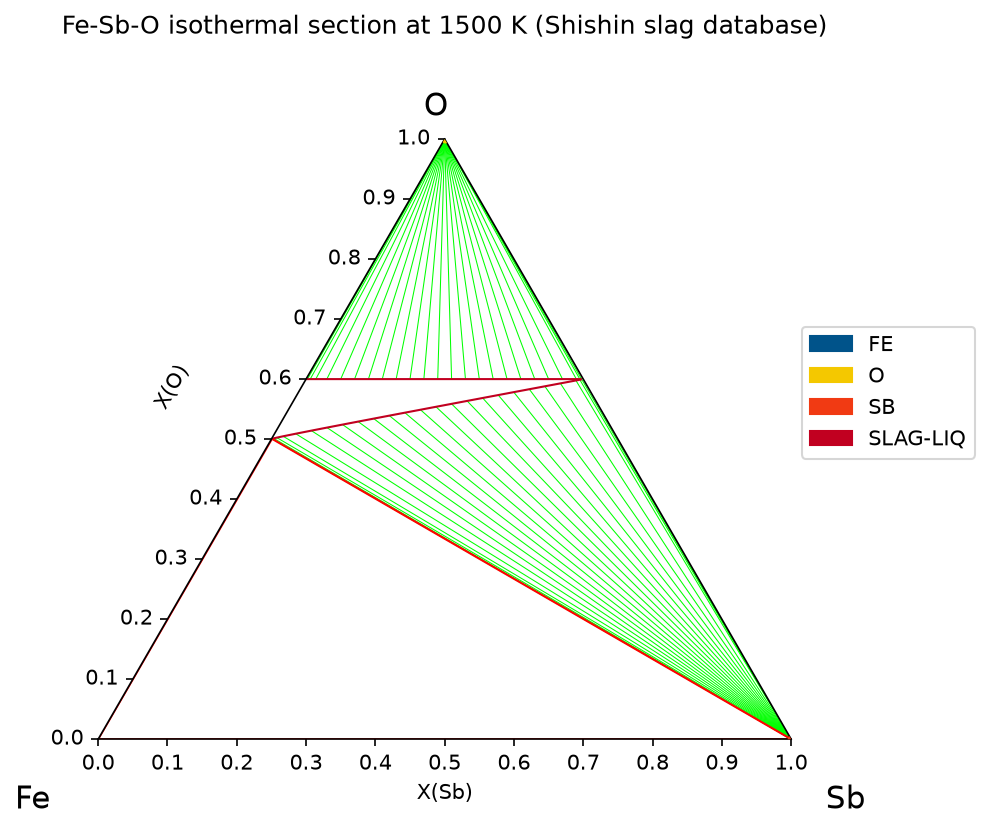

In [6]:
comps = ['FE', 'SB', 'O', 'VA']
phases = list(dbf.phases.keys())
conditions = {v.P: 101325, v.T: 1500, v.X('O'): (0, 1, 0.02), v.X('SB'): (0, 1, 0.02)}

ax = ternplot(dbf, comps, phases, conditions)
ax.text(-0.12, -0.10, 'Fe', size=15, transform=ax.transAxes)
ax.text(0.47, 0.90,  'O',  size=15, transform=ax.transAxes)
ax.text(1.05, -0.10, 'Sb', size=15, transform=ax.transAxes)
ax.set_title('Fe-Sb-O isothermal section at 1500 K (Shishin slag database)')
fig = ax.figure
fig.set_size_inches(9, 6)
fig.set_dpi(150)